In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

Pandas: 2.0.3
Matplotlib: 3.7.2


In [2]:
df = pd.read_csv("data/salesdaily.csv")
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [3]:
print("Shape:", df.shape)
print("\nColunas:", df.columns.tolist())
print("\nTipos de dados:")
print(df.dtypes)

Shape: (2106, 13)

Colunas: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name']

Tipos de dados:
datum            object
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
Year              int64
Month             int64
Hour              int64
Weekday Name     object
dtype: object


In [4]:
# Pergunta 1 — Quantidades totais de vendas por categoria
med_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

total_sales = df[med_columns].sum().sort_values(ascending=False)
print(total_sales)

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64


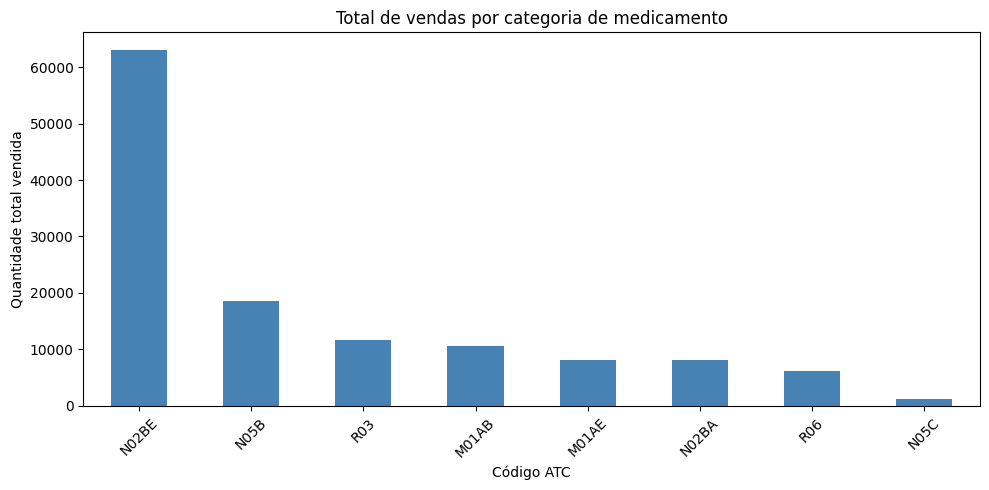

In [5]:
total_sales.plot(kind="bar", figsize=(10, 5), color="steelblue")
plt.title("Total de vendas por categoria de medicamento")
plt.xlabel("Código ATC")
plt.ylabel("Quantidade total vendida")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

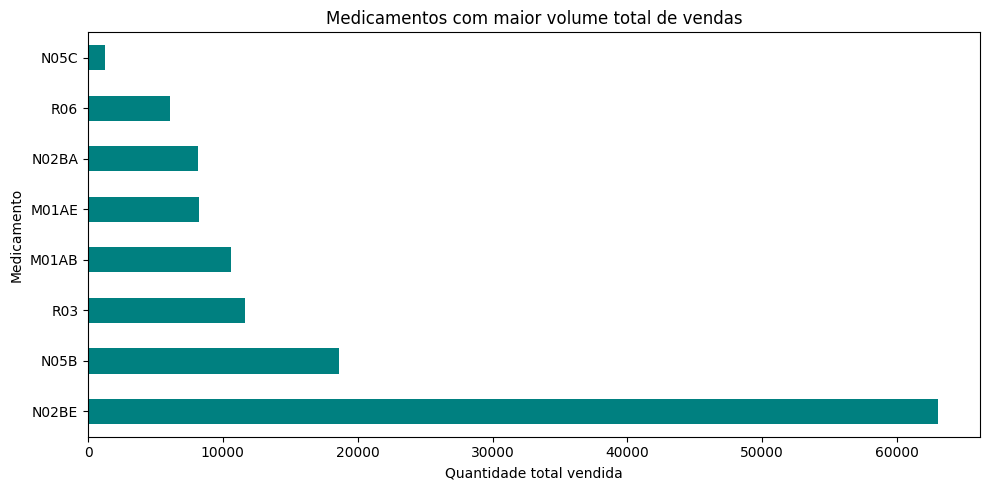

In [8]:
# Pergunta 2 — Medicamentos com maior volume total
top_drugs = df[med_columns].sum().sort_values(ascending=False)

top_drugs.plot(kind="barh", figsize=(10, 5), color="teal")
plt.title("Medicamentos com maior volume total de vendas")
plt.xlabel("Quantidade total vendida")
plt.ylabel("Medicamento")
plt.tight_layout()
plt.show()

In [9]:
# Pergunta 3 — Top 3 medicamentos em períodos específicos
periodos = [
    (2015, 1, "Janeiro 2015"),
    (2016, 7, "Julho 2016"),
    (2017, 9, "Setembro 2017"),
]

for year, month, label in periodos:
    filtro = df[(df["Year"] == year) & (df["Month"] == month)]
    top3 = filtro[med_columns].sum().sort_values(ascending=False).head(3)
    print(f"\n{label}:")
    print(top3)


Janeiro 2015:
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

Julho 2016:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64

Setembro 2017:
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


Medicamento mais vendido em 2017:
N02BE    9258.804833
dtype: float64


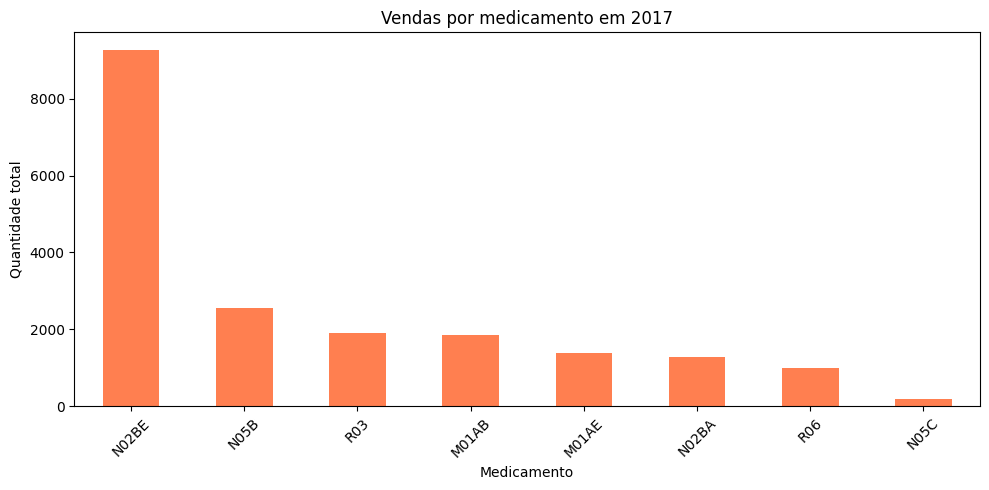

In [11]:
# Pergunta 4 — Medicamento mais vendido em 2017
df_2017 = df[df["Year"] == 2017]
mais_vendido = df_2017[med_columns].sum().sort_values(ascending=False)

print("Medicamento mais vendido em 2017:")
print(mais_vendido.head(1))

mais_vendido.plot(kind="bar", figsize=(10, 5), color="coral")
plt.title("Vendas por medicamento em 2017")
plt.xlabel("Medicamento")
plt.ylabel("Quantidade total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Média de vendas diárias por medicamento:
N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64


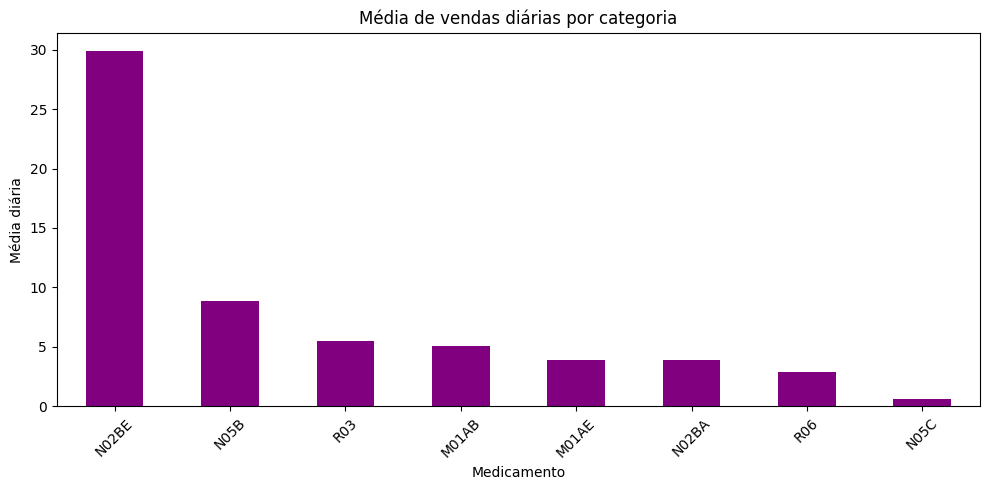

In [12]:
# Pergunta 5 — Maior média de vendas diárias
media_diaria = df[med_columns].mean().sort_values(ascending=False)

print("Média de vendas diárias por medicamento:")
print(media_diaria)

media_diaria.plot(kind="bar", figsize=(10, 5), color="purple")
plt.title("Média de vendas diárias por categoria")
plt.xlabel("Medicamento")
plt.ylabel("Média diária")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

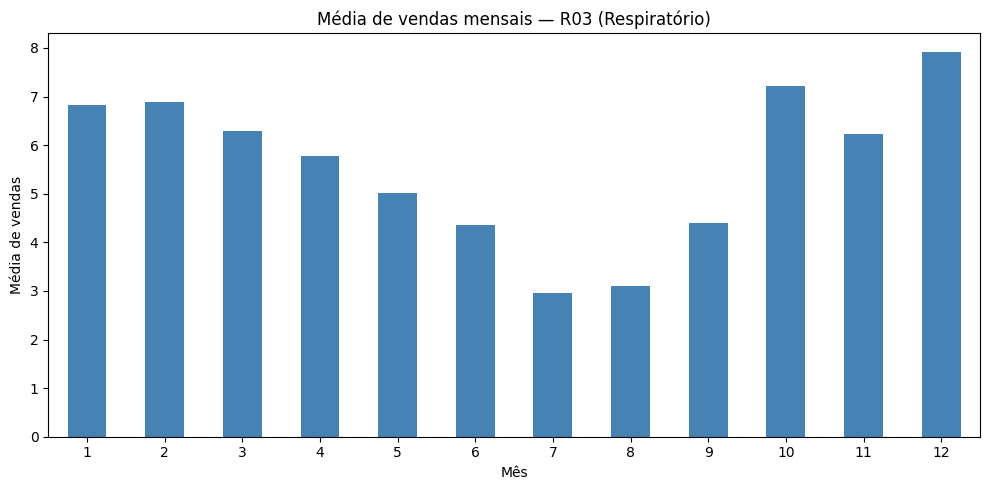

Month
1     6.835980
2     6.896943
3     6.290323
4     5.771528
5     5.006944
6     4.350000
7     2.956989
8     3.102151
9     4.402315
10    7.208589
11    6.226667
12    7.916129
Name: R03, dtype: float64


In [14]:
# Pergunta 6 — Sazonalidade do R03
r03_mensal = df.groupby("Month")["R03"].mean()

r03_mensal.plot(kind="bar", figsize=(10, 5), color="steelblue")
plt.title("Média de vendas mensais — R03 (Respiratório)")
plt.xlabel("Mês")
plt.ylabel("Média de vendas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(r03_mensal)